In [26]:
import torch
import torch.nn as nn
import json
import os
import pandas as pd
from models.lstm import LSTM as LSTM1
from models.lstm_proj_diff import LSTM as LSTM2
from utils.dataset import TranslateDataset
from torch.utils.data import DataLoader
import tokenizers
import numpy as np
from tqdm import tqdm

In [54]:
np.exp(3.5)

np.float64(33.11545195869231)

In [27]:
df_eval = pd.read_parquet("data/tokenized_eval.parquet")
# df_train = pd.read_parquet("data/tokenized_train.parquet").sample(n=100, random_state=42).reset_index(drop=True)

In [28]:
tokenizer = tokenizers.Tokenizer.from_file("artifacts/tokenizer_50000.json")

In [39]:
dataset_eval = TranslateDataset(
    tokens_src=df_eval['en_tokens_50000'].tolist(),
    tokens_tgt=df_eval['pt_tokens_50000'].tolist(),
    invert_src=False,
    max_len=64
)

dataloader_eval = DataLoader(dataset_eval, batch_size=64, shuffle=False)

In [40]:
MODELS_TRY = [
    LSTM2
]

In [41]:
PATH_MODELS = "artifacts"

models = {}
for file in os.listdir(PATH_MODELS):
    if file.endswith(".pt"):
        model_name = file.split(".")[0].replace('model_', '')
        if('v32' not in model_name):
           continue
        print(f'Lendo {model_name}')
        model_path = os.path.join(PATH_MODELS, file)
        model_config_path = os.path.join("configs", f"{model_name}_config.json")
        
        with open(model_config_path, 'r', encoding='utf-8') as f:
            model_config = json.load(f)
        
        for MODEL_TRY in MODELS_TRY:
            try:
                model = MODEL_TRY(embedding_dim=model_config["embedding_dim"],
                            encoder_bidirectional=model_config["encoder_bidirectional"],
                            encoder_hidden_dim=model_config["encoder_hidden_dim"],
                            encoder_num_layers=model_config["encoder_num_layers"],
                            decoder_hidden_dim=model_config["decoder_hidden_dim"],
                            decoder_num_layers=model_config["decoder_num_layers"],
                            encoder_dropout=model_config["encoder_dropout"],
                            decoder_dropout=model_config["decoder_dropout"],
                            vocab_size=model_config["vocab_size"] if "vocab_size" in model_config else 10000, 
                            pad_idx=0)
                model.load_state_dict(torch.load(model_path))
                model.to("cuda" if torch.cuda.is_available() else "cpu")
                model.eval()
                models[model_name] = model
                break
            except RuntimeError as e:
                print(str(e))
                continue

Lendo v32


In [42]:
print(models.keys())

dict_keys(['v32'])


In [43]:
for model_name, model in models.items():

    print(f"Model: {model_name}")

    decoded_outputs = []

    for batch in tqdm(dataloader_eval):

        enc_tokens, _ = batch

        enc_tokens = enc_tokens.to('cuda')
        

        with torch.no_grad():

            outputs = model.predict(
                src=enc_tokens,
                bos_token_id=5,
                eos_token_id=6,
                max_len=64
            )

        decoded_outputs.extend(
            tokenizer.decode_batch(
                outputs.cpu().tolist(),
                skip_special_tokens=False
            )
        )

    df_eval[f'{model_name}_pred'] = decoded_outputs

Model: v32


100%|██████████| 627/627 [00:18<00:00, 33.26it/s]


In [44]:
model_name

'v32'

In [45]:
df_configs = pd.DataFrame([json.load(open(os.path.join("configs", f))) for f in os.listdir("configs") if f.endswith("_config.json")])
df_configs.loc[df_configs['name'].isin(models.keys())].to_dict(orient='records')

[{'invert_src': False,
  'embedding_dim': 384,
  'encoder_hidden_dim': 1024,
  'decoder_hidden_dim': 1024,
  'encoder_num_layers': 3,
  'decoder_num_layers': 3,
  'encoder_dropout': 0.4,
  'decoder_dropout': 0.4,
  'encoder_bidirectional': True,
  'batch_size': 128,
  'accum_steps': 1,
  'log_steps': 500,
  'save_steps': 1000,
  'eval_steps': 1000,
  'device': 'cuda',
  'desc': 'Aumentando o max steps',
  'name': 'v32',
  'early_stop_patience': 20,
  'early_stop_min_delta': 0.0,
  'warmup_steps': 25000.0,
  'max_steps': 500000.0,
  'learning_rate': 0.0001,
  'vocab_size': 50000.0,
  'max_len': nan,
  'clip_grad': nan,
  'init_weight_method': nan,
  'init_bias_method': nan}]

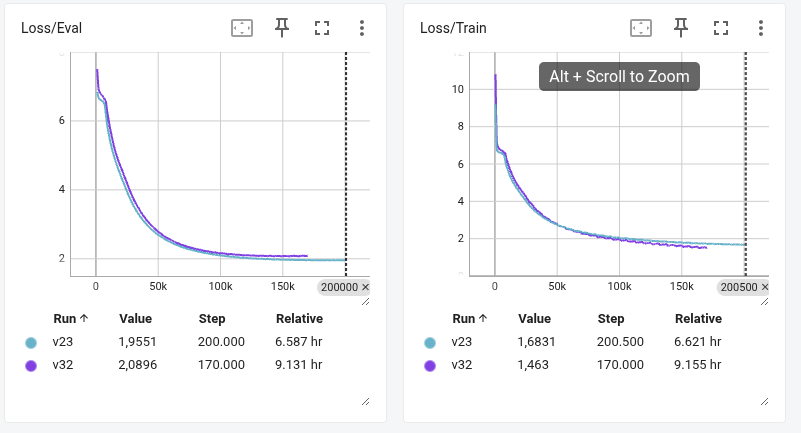

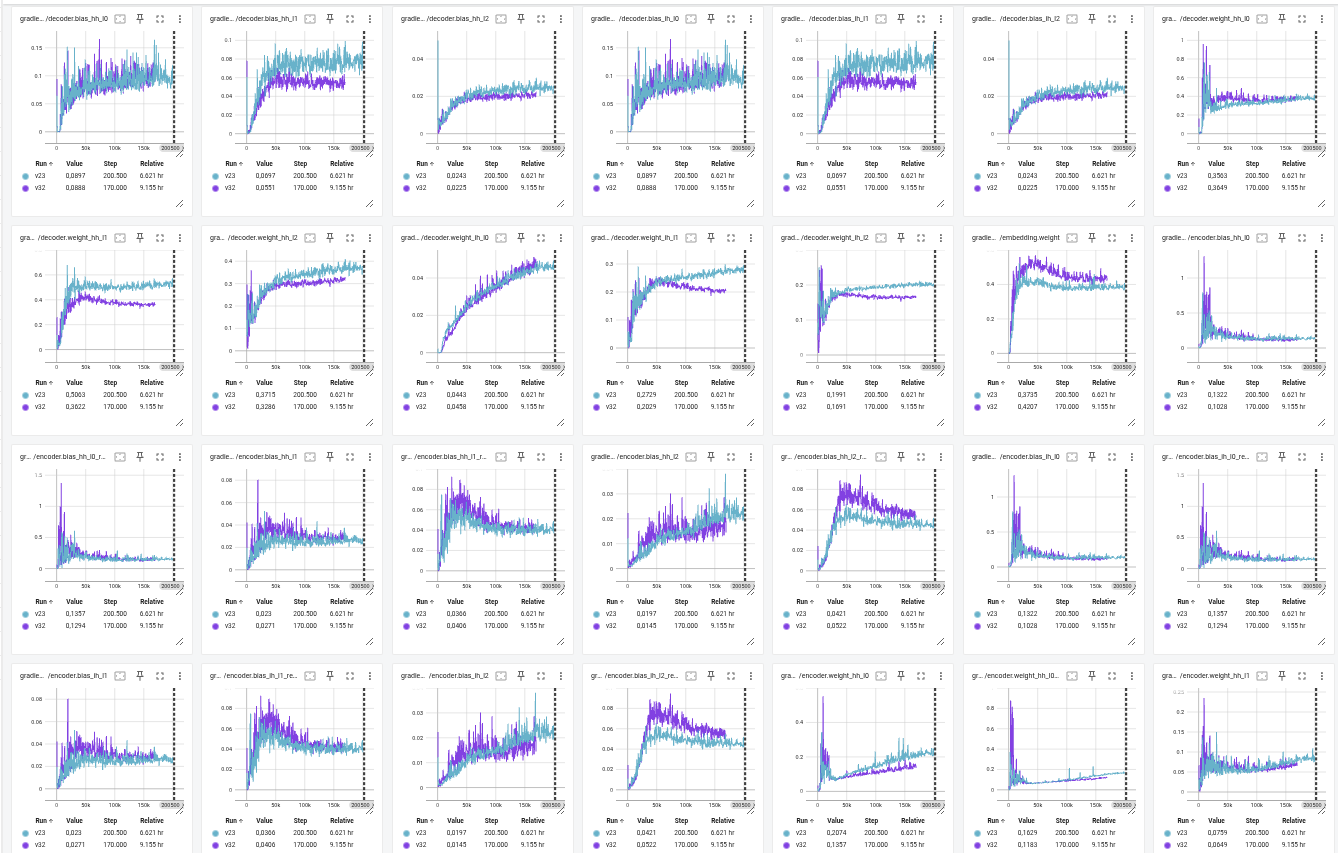

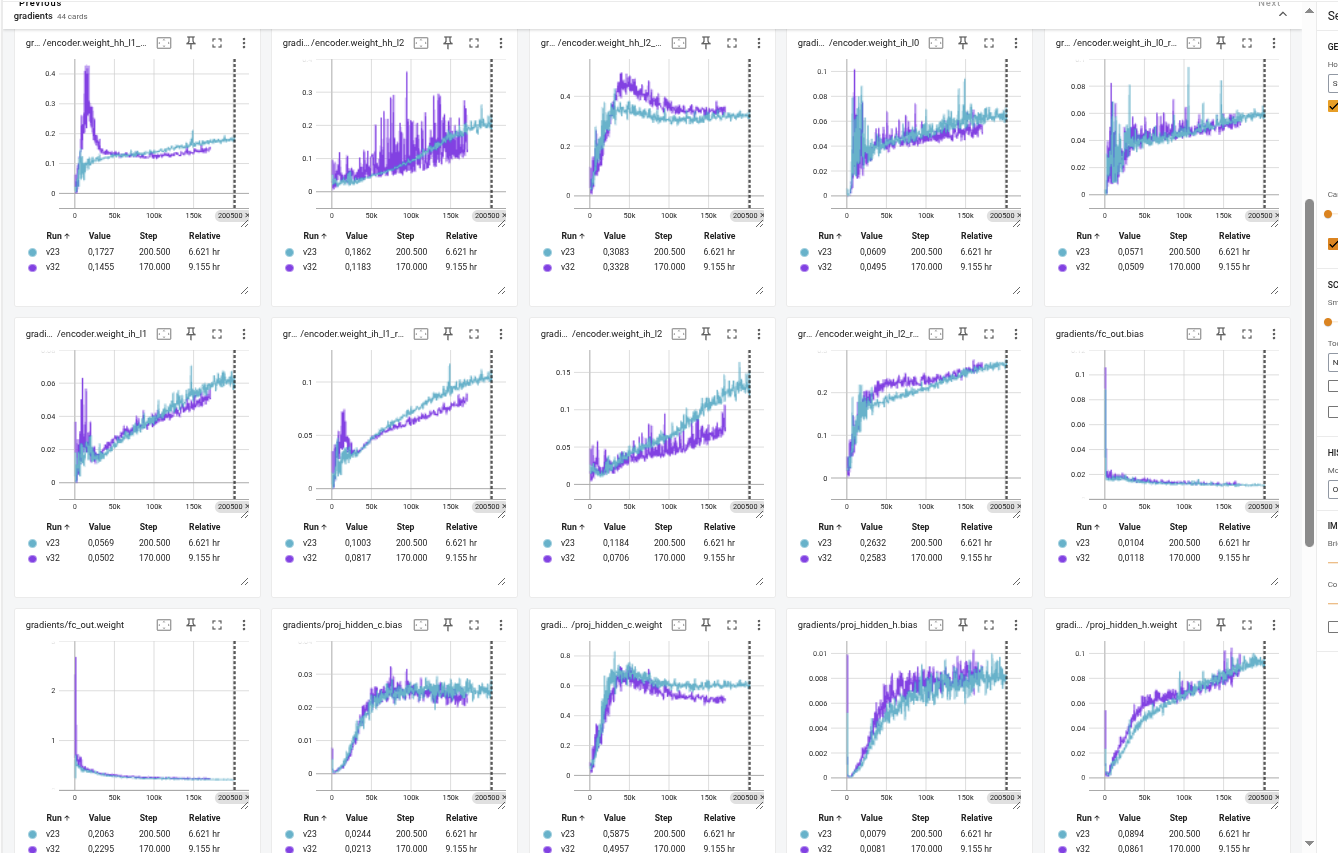

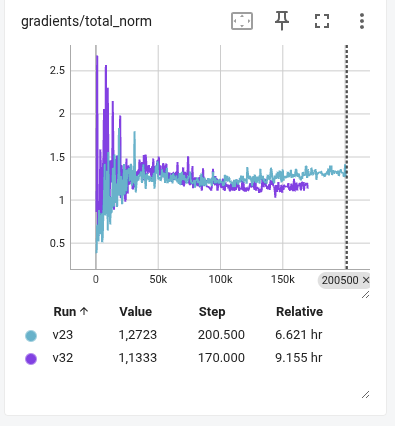

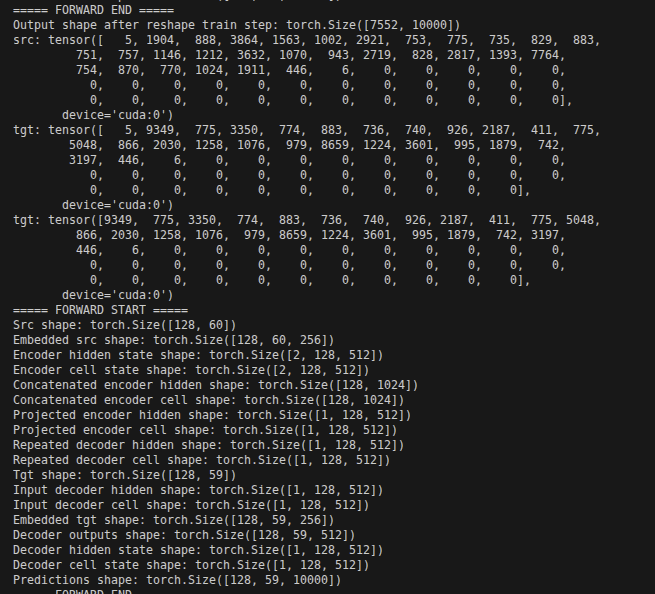

In [46]:
df_eval.loc[df_eval['pt'].str.lower().str.contains('faça um trabalho')]

,en,pt,en_length,pt_length,en_max_len_word,pt_max_len_word,en_tokens_10000,pt_tokens_10000,en_tokens_50000,pt_tokens_50000,v32_pred


In [48]:
for index in np.random.choice(len(df_eval), size=100, replace=False):
    print('Inglês:', df_eval['en'].iloc[index])
    print('Português:', df_eval['pt'].iloc[index])
    for model_test in ['v32_pred']:
        print(f'{model_test}:', df_eval[model_test].iloc[index])
    print('-'*200)

Inglês: Sir ishida, although this is how i've ended up with gin, i know her character very well after being together for three years.
Português: Sr. ishida, embora eu tenha terminado assim com gin, eu conheço seu caráter muito bem e por ter estado com ela por três anos.
v32_pred: ípicos de morte . <EOS>. <EOS>. <EOS>. <EOS>. <EOS>. <EOS>
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Inglês: Oh, and speaking of crime, you'll recall rafael's sister luisa was dating eileen, but eileen is really her old girlfriend, rose, aka the crime lord sin rostro.
Português: E falando em crime... lembram da irmã de rafael, luisa que namorava eileen, mas eileen era sua ex-namorada, rose, ela era a criminosa sin rostro.
v32_pred: , mas não sei . <EOS>. <EOS>. <EOS>. <EOS>. <EOS>. <EOS>. <EOS>. <EOS>. <EOS>. <EOS>. <EOS>. <EOS>. <EOS>. <EOS>. <EOS>. <EO